In [381]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display


In [382]:
df_laadpark = pd.read_csv('data/ev_consumption.csv', parse_dates=['Date'])
df_2024 = pd.read_excel('data/energie_orac_2024.xlsx', parse_dates=['datetime'])
df_2025 = pd.read_excel('data/energie_orac_2025.xlsx', parse_dates=['datetime'])
df_2026 = pd.read_excel('data/energie_orac_2026.xlsx', parse_dates=['datetime'])
df_laadsessies = pd.read_excel('data/Sessions (1) (1).xlsx', parse_dates=['From', 'To'])

In [383]:
df_laadpark.head()

,Date,total_consumption_ev
0,2025-05-06 00:00:00,0.005
1,2025-05-06 01:00:00,0.006
2,2025-05-06 02:00:00,0.006
3,2025-05-06 03:00:00,0.006
4,2025-05-06 04:00:00,0.006


In [384]:
df_2024.head()

,datetime,afname_kwh,injectie_kwh,productie_kwh
0,2024-01-01 00:00:00,10.625,0.0,0.0
1,2024-01-01 00:15:00,10.625,0.0,0.0
2,2024-01-01 00:30:00,11.875,0.0,0.0
3,2024-01-01 00:45:00,13.750,0.0,0.0
4,2024-01-01 01:00:00,14.375,0.0,0.0


In [385]:
#aantal rijen in df_laadsessies
print(len(df_laadsessies))


3608


In [386]:
#resample df_2024, df_2025, df_2026 to 1h 
df_2024.set_index('datetime', inplace=True)
df_2024 = df_2024.resample('1h').sum()
df_2025.set_index('datetime', inplace=True)
df_2025 = df_2025.resample('1h').sum()
df_2026.set_index('datetime', inplace=True)
df_2026 = df_2026.resample('1h').sum()

In [387]:
df_2024.head()

,afname_kwh,injectie_kwh,productie_kwh
datetime,,,
2024-01-01 00:00:00,46.875,0.0,0.0
2024-01-01 01:00:00,54.375,0.0,0.0
2024-01-01 02:00:00,51.875,0.0,0.0
2024-01-01 03:00:00,53.125,0.0,0.0
2024-01-01 04:00:00,71.875,0.0,0.0


In [388]:
print(df_2024["injectie_kwh"].sum())

529468.26


In [389]:
df_2024.head()

,afname_kwh,injectie_kwh,productie_kwh
datetime,,,
2024-01-01 00:00:00,46.875,0.0,0.0
2024-01-01 01:00:00,54.375,0.0,0.0
2024-01-01 02:00:00,51.875,0.0,0.0
2024-01-01 03:00:00,53.125,0.0,0.0
2024-01-01 04:00:00,71.875,0.0,0.0


In [390]:
df_laadpark.head()

,Date,total_consumption_ev
0,2025-05-06 00:00:00,0.005
1,2025-05-06 01:00:00,0.006
2,2025-05-06 02:00:00,0.006
3,2025-05-06 03:00:00,0.006
4,2025-05-06 04:00:00,0.006


In [391]:
# Startdatums bepalen
df_laadpark['Date'] = pd.to_datetime(df_laadpark['Date'])
df_laadpark = df_laadpark.set_index('Date')

start_2024 = df_2024.index.min()
start_laadpark = df_laadpark.index.min()

offset = start_laadpark - start_2024

df_2024_shifted = df_2024.copy()
df_2024_shifted.index = df_2024_shifted.index + offset

print("Originele start:", start_2024)
print("Nieuwe start:", df_2024_shifted.index.min())
print("Laadpark start:", start_laadpark)

Originele start: 2024-01-01 00:00:00
Nieuwe start: 2025-05-06 00:00:00
Laadpark start: 2025-05-06 00:00:00


In [392]:
df_2024_shifted.head()

,afname_kwh,injectie_kwh,productie_kwh
datetime,,,
2025-05-06 00:00:00,46.875,0.0,0.0
2025-05-06 01:00:00,54.375,0.0,0.0
2025-05-06 02:00:00,51.875,0.0,0.0
2025-05-06 03:00:00,53.125,0.0,0.0
2025-05-06 04:00:00,71.875,0.0,0.0


In [393]:
df_2025_2026 = pd.concat([df_2025, df_2026])
df_2025_2026.head()

,afname_kwh,injectie_kwh,productie_kwh
datetime,,,
2025-01-01 00:00:00,43.125,0.0,0.0
2025-01-01 01:00:00,47.500,0.0,0.0
2025-01-01 02:00:00,53.125,0.0,0.0
2025-01-01 03:00:00,50.000,0.0,0.0
2025-01-01 04:00:00,65.625,0.0,0.0


In [394]:
start_ev = df_laadpark.index.min()
end_ev = df_laadpark.index.max()

start_2025_2026 = df_2025_2026.index.min()

offset = start_ev - start_2025_2026

df_2025_2026_shifted = df_2025_2026.copy()
df_2025_2026_shifted.index = df_2025_2026_shifted.index + offset

df_2025_2026_shifted = df_2025_2026_shifted.loc[start_ev:end_ev]

In [395]:
df_2025_2026_shifted.head()

,afname_kwh,injectie_kwh,productie_kwh
datetime,,,
2025-05-06 00:00:00,43.125,0.0,0.0
2025-05-06 01:00:00,47.500,0.0,0.0
2025-05-06 02:00:00,53.125,0.0,0.0
2025-05-06 03:00:00,50.000,0.0,0.0
2025-05-06 04:00:00,65.625,0.0,0.0


In [396]:
df_2024_clean = df_2024_shifted[['injectie_kwh', 'productie_kwh']].copy()
df_2025_2026_clean = df_2025_2026_shifted[['afname_kwh']].copy()
df_laadpark_clean = df_laadpark[['total_consumption_ev']].copy()

In [397]:
df_main = (
    df_2024_clean
    .join(df_2025_2026_clean, how='outer')
    .join(df_laadpark_clean, how='outer')
    .sort_index()
)

In [398]:
df_main = df_main.loc[df_laadpark.index.min():df_laadpark.index.max()]

In [399]:
df_main.head(50)

,injectie_kwh,productie_kwh,afname_kwh,total_consumption_ev
datetime,,,,
2025-05-06 00:00:00,0.00,0.000000,43.125,0.005
2025-05-06 01:00:00,0.00,0.000000,47.500,0.006
2025-05-06 02:00:00,0.00,0.000000,53.125,0.006
2025-05-06 03:00:00,0.00,0.000000,50.000,0.006
2025-05-06 04:00:00,0.00,0.000000,65.625,0.006
2025-05-06 05:00:00,0.00,0.000000,65.625,0.006
2025-05-06 06:00:00,0.00,0.000000,56.875,0.006
2025-05-06 07:00:00,0.00,0.000000,61.250,3.147
2025-05-06 08:00:00,0.00,0.413450,59.375,55.231


In [400]:
#Print injectie sum & laadverbruik sum en afronden en kwh erbij zetten
injectie_sum = df_main['injectie_kwh'].sum()
laadverbruik_sum = df_main['total_consumption_ev'].sum()
print(f"Totale injectie: {injectie_sum:.2f} kWh")
print(f"Totale laadverbruik: {laadverbruik_sum:.2f} kWh")

Totale injectie: 528396.32 kWh
Totale laadverbruik: 106465.10 kWh


In [401]:
df_main["totaal_verbruik_kwh"] = df_main['afname_kwh'] + df_main['productie_kwh'] - df_main['injectie_kwh']

In [402]:
df_main['totaal_verbruik_gebouw'] = df_main['totaal_verbruik_kwh'] - df_main['total_consumption_ev']
df_main.head()

,injectie_kwh,productie_kwh,afname_kwh,total_consumption_ev,totaal_verbruik_kwh,totaal_verbruik_gebouw
datetime,,,,,,
2025-05-06 00:00:00,0.0,0.0,43.125,0.005,43.125,43.120
2025-05-06 01:00:00,0.0,0.0,47.500,0.006,47.500,47.494
2025-05-06 02:00:00,0.0,0.0,53.125,0.006,53.125,53.119
2025-05-06 03:00:00,0.0,0.0,50.000,0.006,50.000,49.994
2025-05-06 04:00:00,0.0,0.0,65.625,0.006,65.625,65.619


In [403]:
df_main.head()

,injectie_kwh,productie_kwh,afname_kwh,total_consumption_ev,totaal_verbruik_kwh,totaal_verbruik_gebouw
datetime,,,,,,
2025-05-06 00:00:00,0.0,0.0,43.125,0.005,43.125,43.120
2025-05-06 01:00:00,0.0,0.0,47.500,0.006,47.500,47.494
2025-05-06 02:00:00,0.0,0.0,53.125,0.006,53.125,53.119
2025-05-06 03:00:00,0.0,0.0,50.000,0.006,50.000,49.994
2025-05-06 04:00:00,0.0,0.0,65.625,0.006,65.625,65.619


In [404]:
N_LAADPUNTEN = 20
P_MAX_PUNT_KW = 11
P_MAX_TOTAAL = 220

def strategie_1_ongecoordineerd(df, n_laadpunten, p_max_punt, laadbehoefte_serie):
    """
    Aangepast: gebruikt nu laadbehoefte_serie in plaats van de hardcoded kolom
    """
    p_max = n_laadpunten * p_max_punt
    P_laad = pd.Series(0.0, index=df.index)

    werkdagen = df.index[df.index.dayofweek < 5].normalize().unique()

    for dag in werkdagen:
        mask_dag = df.index.normalize() == dag
        mask_aanwezig = mask_dag & (df.index.hour >= int(AANKOMST_H)) & (df.index.hour < int(VERTREK_H))
        idx_dag = df.index[mask_aanwezig]

        if len(idx_dag) == 0:
            continue

        # Gebruik hier de variabele laadbehoefte_serie in plaats van df['total_consumption_ev']
        energie_nodig = laadbehoefte_serie.loc[idx_dag].sum()
        energie_geladen = 0.0

        for t in idx_dag:
            energie_tekort = max(0.0, energie_nodig - energie_geladen)
            if energie_tekort <= 0:
                break

            p = min(p_max, energie_tekort / TIJDSTAP_H)
            P_laad[t] = p
            energie_geladen += p * TIJDSTAP_H

    return P_laad.rename('P_laad_S1')

In [ ]:
df_main['P_laad_S1'] = strategie_1_ongecoordineerd(
    df_main,
    n_laadpunten=N_LAADPUNTEN,
    p_max_punt=P_MAX_PUNT_KW,
    laadbehoefte_serie=df_main['total_consumption_ev']

)

df_main['P_net_S1'] = df_main['afname_kwh']

In [406]:
df_main.head()

,injectie_kwh,productie_kwh,afname_kwh,total_consumption_ev,totaal_verbruik_kwh,totaal_verbruik_gebouw,P_laad_S1,P_net_S1
datetime,,,,,,,,
2025-05-06 00:00:00,0.0,0.0,43.125,0.005,43.125,43.120,0.0,43.120
2025-05-06 01:00:00,0.0,0.0,47.500,0.006,47.500,47.494,0.0,47.494
2025-05-06 02:00:00,0.0,0.0,53.125,0.006,53.125,53.119,0.0,53.119
2025-05-06 03:00:00,0.0,0.0,50.000,0.006,50.000,49.994,0.0,49.994
2025-05-06 04:00:00,0.0,0.0,65.625,0.006,65.625,65.619,0.0,65.619


In [435]:
import math
import pandas as pd

def strategie_2_smart_zc(df, n_laadpunten, p_max_punt, laadbehoefte_serie):
    """
    Strategie 2: Aan/Uit laden (Geen gereduceerd vermogen).
    - Wacht op zon: Auto's laden direct als PV > VERBRUIK.
    - Vol vermogen: Als ze laden, trekken ze direct maximaal vermogen (p_max). 
      Wat de zon niet dekt, komt van het net.
    - Nood-laden: Gecorrigeerd met math.ceil zodat SOC_vertrek >= SOC_min ALTIJD wordt gehaald.
    """
    p_max = n_laadpunten * p_max_punt
    P_laad = pd.Series(0.0, index=df.index)

    werkdagen = df.index[df.index.dayofweek < 5].normalize().unique()

    for dag in werkdagen:
        mask_dag = (df.index.normalize() == dag)
        mask_aanwezig = mask_dag & (df.index.hour >= int(AANKOMST_H)) & (df.index.hour < int(VERTREK_H))
        idx_dag = df.index[mask_aanwezig]

        if len(idx_dag) == 0:
            continue

        energie_nodig = (laadbehoefte_serie[mask_aanwezig] * TIJDSTAP_H).sum()
        energie_geladen = 0.0
        stappen_rest = len(idx_dag)

        for t in idx_dag:
            pv_overschot = df.loc[t, 'productie_kwh'] - df.loc[t, 'totaal_verbruik_gebouw']
            energie_tekort = max(0.0, energie_nodig - energie_geladen)
            
            if energie_tekort <= 0:
                stappen_rest -= 1
                continue
                
            # --- CORRECTIE: math.ceil() toegevoegd om naar boven af te ronden ---
            stappen_nodig_om_vol_te_raken = math.ceil(energie_tekort / (p_max * TIJDSTAP_H))
            
            # LOGICA: We gaan laden op MAXIMAAL vermogen als:
            # 1. PV > VERBRUIK (pv_overschot > 0)
            # 2. OF we hebben geen tijd meer om te wachten (stappen_rest <= afgeronde stappen_nodig)
            if pv_overschot > 0 or stappen_rest <= stappen_nodig_om_vol_te_raken:
                p = min(p_max, energie_tekort / TIJDSTAP_H)
            else:
                p = 0.0 

            P_laad[t] = p
            energie_geladen += p * TIJDSTAP_H
            stappen_rest -= 1

    return P_laad.rename('P_laad_S2')

In [436]:
df_main['P_laad_S2'] = strategie_2_smart_zc(
    df_main, 
    n_laadpunten=N_LAADPUNTEN, 
    p_max_punt=P_MAX_PUNT_KW,
    laadbehoefte_serie=df_main['total_consumption_ev']
)

df_main['P_net_S2'] = (
    df_main['totaal_verbruik_gebouw']
    + df_main['P_laad_S2']
    - df_main['productie_kwh']
)

In [437]:
def strategie_3_smart_zc_piek(df, n_laadpunten, p_max_punt, p_net_cap, laad_basis_col='P_laad_S1'):
    p_max = n_laadpunten * p_max_punt
    P_laad = pd.Series(0.0, index=df.index)

    # AANPASSING: Zorg dat de functie zowel een kolomnaam (string) als een Series accepteert
    if isinstance(laad_basis_col, str):
        laad_basis_series = df[laad_basis_col]
    else:
        laad_basis_series = laad_basis_col

    werkdagen = df.index[df.index.dayofweek < 5].normalize().unique()

    for dag in werkdagen:
        mask_dag = (df.index.normalize() == dag)
        mask_aanwezig = mask_dag & (df.index.hour >= int(AANKOMST_H)) & (df.index.hour < int(VERTREK_H))
        idx_dag = df.index[mask_aanwezig]

        if len(idx_dag) == 0:
            continue

        # AANPASSING: We gebruiken nu laad_basis_series.loc in plaats van df.loc
        energie_nodig = (laad_basis_series.loc[idx_dag] * TIJDSTAP_H).sum()
        energie_geladen = 0.0
        stappen_rest = len(idx_dag)

        for t in idx_dag:
            pv_overschot = max(0.0, df.loc[t, 'productie_kwh'] - df.loc[t, 'totaal_verbruik_gebouw'])
            net_zonder_ev = df.loc[t, 'totaal_verbruik_gebouw'] - df.loc[t, 'productie_kwh']
            energie_tekort = max(0.0, energie_nodig - energie_geladen)
            minimum_nodig = energie_tekort / (stappen_rest * TIJDSTAP_H) if stappen_rest > 0 else 0.0

            vermogen_target = min(p_max, energie_tekort / TIJDSTAP_H)

            if net_zonder_ev + p_max > p_net_cap:
                p_cap = max(0.0, p_net_cap - net_zonder_ev)
            else:
                p_cap = p_max

            p = min(vermogen_target, p_cap, max(pv_overschot, minimum_nodig))

            P_laad[t] = max(0.0, min(p, p_max))
            energie_geladen += P_laad[t] * TIJDSTAP_H
            stappen_rest -= 1

    P_net = df['totaal_verbruik_gebouw'] + P_laad - df['productie_kwh']
    P_net = P_net.clip(upper=p_net_cap)

    return P_laad.rename('P_laad_S3'), P_net.rename('P_net_S3')

In [438]:
P_NET_CAP = 605  # Of 580, afhankelijk van je definitieve keuze

df_main['P_laad_S3'], df_main['P_net_S3'] = strategie_3_smart_zc_piek(
    df_main,
    N_LAADPUNTEN,
    P_MAX_PUNT_KW,
    P_NET_CAP,
    laad_basis_col='P_laad_S1' # Kijkt naar de basis S1
)

In [439]:
# ============================================================
# EXTRA SCENARIO'S: +5 LAADPALEN (= +10 PUNTEN) EN +10 LAADPALEN (= +20 PUNTEN)
# ============================================================

def maak_extra_scenario(df, suffix, extra_laadpalen):
    # 1. Bereken de verhouding (bijv. 30 punten / 20 punten = 1.5)
    n_laadpunten = N_LAADPUNTEN + extra_laadpalen
    factor = n_laadpunten / N_LAADPUNTEN
    
    # 2. Maak een kopie van de laadvraag voor dit scenario
    # Dit zorgt ervoor dat S1, S2 en S3 nu rekenen met de verhoogde vraag
    laadvraag_scenario = df['total_consumption_ev'] * factor
    
    s1_col = f'P_laad_S1_{suffix}'
    s2_col = f'P_laad_S2_{suffix}'
    s3_col = f'P_laad_S3_{suffix}'

    # 3. Geef de nieuwe 'laadvraag_scenario' mee aan je strategie functies
    # LET OP: Jouw huidige functies moeten 'total_consumption_ev' als parameter accepteren
    # in plaats van dat ze hardcoded in de functie naar df['total_consumption_ev'] kijken.
    
    df[s1_col] = strategie_1_ongecoordineerd(df, n_laadpunten, P_MAX_PUNT_KW, laadvraag_scenario)
    df[f'P_net_S1_{suffix}'] = df['totaal_verbruik_gebouw'] + df[s1_col] - df['productie_kwh']

    df[s2_col] = strategie_2_smart_zc(df, n_laadpunten, P_MAX_PUNT_KW, laadvraag_scenario)
    df[f'P_net_S2_{suffix}'] = df['totaal_verbruik_gebouw'] + df[s2_col] - df['productie_kwh']

    df[s3_col], df[f'P_net_S3_{suffix}'] = strategie_3_smart_zc_piek(
        df,
        n_laadpunten,
        P_MAX_PUNT_KW,
        P_NET_CAP,
        laad_basis_col=s1_col # S3 gebruikt S1 als basis voor de energiebehoefte
    )

    return [s1_col, s2_col, s3_col, f'P_net_S1_{suffix}', f'P_net_S2_{suffix}', f'P_net_S3_{suffix}']

extra_kolommen_5 = maak_extra_scenario(df_main, 'plus10p', 5)
extra_kolommen_10 = maak_extra_scenario(df_main, 'plus20p', 10)

print('Extra scenario-kolommen aangemaakt ✓')
print('5 extra laadpalen:', extra_kolommen_5)
print('10 extra laadpalen:', extra_kolommen_10)

Extra scenario-kolommen aangemaakt ✓
5 extra laadpalen: ['P_laad_S1_plus10p', 'P_laad_S2_plus10p', 'P_laad_S3_plus10p', 'P_net_S1_plus10p', 'P_net_S2_plus10p', 'P_net_S3_plus10p']
10 extra laadpalen: ['P_laad_S1_plus20p', 'P_laad_S2_plus20p', 'P_laad_S3_plus20p', 'P_net_S1_plus20p', 'P_net_S2_plus20p', 'P_net_S3_plus20p']


In [440]:
# ============================================================
# CEL 3 – PARAMETERS (GEFIXTE VERSIE)
# ============================================================

# --- Tijdinstellingen ---
TIJDSTAP_MIN = 60
TIJDSTAP_H = TIJDSTAP_MIN / 60

# --- EV & laadpark ---
N_EV_VLOOT = 35
N_LAADPUNTEN = 20
P_MAX_PUNT_KW = 11

P_MAX_TOTAAL = N_LAADPUNTEN * P_MAX_PUNT_KW  # 220 kW theoretisch max

AANKOMST_H = 8.0
VERTREK_H = 17.0

# ============================================================
# NET PARAMETERS (FLUVIUS)
# ============================================================

P_NET_MAX_KW = 620  # contractueel toegangsvermogen

# Capaciteitstarief (maandpiek gebaseerd)
TARIEF_CAPACITEIT_EUR_PER_KW_MAAND = 3.01

# Toegangsvermogen (vaste netwerkcomponent indien van toepassing)
TARIEF_TOEGANG_EUR_PER_KW_MAAND = 4.52


# ============================================================
# ENERGIE PRIJZEN (€/kWh)
# ============================================================

KLIK_INDEX = 89.737065  # €/MWh

# Energie (markt + levering)
TARIEF_PIEK_URU = KLIK_INDEX * 0.0014136 + 0.0075913
TARIEF_DAL_URU  = KLIK_INDEX * 0.0010510 + 0.0075913

# Netkosten & heffingen
KOST_GROENE_STROOM = 0.0110000
KOST_WKK = 0.0040810
BIJZONDERE_ACCIJNS = 0.0110018
ODV_PIEK = 0.0037033
ODV_DAL = 0.0037033
TOESLAG_E801 = 0.0002193

VASTE_EXTRA = (
    KOST_GROENE_STROOM +
    KOST_WKK +
    BIJZONDERE_ACCIJNS +
    TOESLAG_E801
)

TARIEF_AFNAME_PIEK = TARIEF_PIEK_URU + ODV_PIEK + VASTE_EXTRA
TARIEF_AFNAME_DAL  = TARIEF_DAL_URU  + ODV_DAL  + VASTE_EXTRA

TARIEF_AFNAME_GEM = 0.1761


# ============================================================
# INJECTIE (PV EXPORT)
# ============================================================

TARIEF_INJECTIE_GEM = ((57.98 - 15.58) +
                       (74.53 - 14.83) +
                       (74.795 - 14.75)) / 3 / 1000


# ============================================================
# PIEK DEFINITIE
# ============================================================

def is_piekuur(index):
    return (index.dayofweek < 5) & (index.hour >= 7) & (index.hour < 22)


# ============================================================
# COST MODEL FUNCTIES
# ============================================================

def bereken_maandpiek(df, column="P_net_kW"):
    """
    Berekent maandelijkse piek (Fluvius capaciteitstarief basis)
    """
    return df[column].resample("M").max()


def bereken_capaciteitstarief_kost(maandpiek_series):
    """
    €/kW/maand * maandpiek
    """
    return maandpiek_series * TARIEF_CAPACITEIT_EUR_PER_KW_MAAND


def bereken_toegangstarief_kost():
    """
    Vast vermogen kost (indien toegepast)
    """
    return P_NET_MAX_KW * TARIEF_TOEGANG_EUR_PER_KW_MAAND


def totale_netkost(df):
    """
    Volledig Fluvius kostenmodel
    """
    maandpiek = bereken_maandpiek(df)

    capaciteit = bereken_capaciteitstarief_kost(maandpiek).sum()
    toegang = bereken_toegangstarief_kost()

    return capaciteit + toegang


# ============================================================
# OUTPUT INFO
# ============================================================

print("=" * 50)
print(f"EV's: {N_EV_VLOOT} | Laadpunten: {N_LAADPUNTEN}")
print(f"Max laadvermogen: {P_MAX_TOTAAL} kW")
print(f"Netgrens: {P_NET_MAX_KW} kW")
print(f"Capaciteitstarief: {TARIEF_CAPACITEIT_EUR_PER_KW_MAAND} €/kW/maand")
print(f"Toegangstarief: {TARIEF_TOEGANG_EUR_PER_KW_MAAND} €/kW/maand")
print("=" * 50)

EV's: 35 | Laadpunten: 20
Max laadvermogen: 220 kW
Netgrens: 620 kW
Capaciteitstarief: 3.01 €/kW/maand
Toegangstarief: 4.52 €/kW/maand


In [441]:
import pandas as pd
from IPython.display import display

# ============================================================
# KPI FUNCTION
# ============================================================
def bereken_kpi(df, s_label, s_laad, s_net):

    # ============================================================
    # S0 BASELINE (GEBOUW ONLY, GEEN EV)
    # ============================================================
    if s_label == 'S0 – Geen EV':
        P_laad = pd.Series(0.0, index=df.index)
        P_net  = df['totaal_verbruik_gebouw'] - df['productie_kwh']
    else:
        P_laad = df[s_laad]
        P_net  = df[s_net]

    P_pv = df['productie_kwh']

    # ============================================================
    # ENERGIE
    # ============================================================
    E_laad = (P_laad * TIJDSTAP_H).sum()
    E_afname = (P_net.clip(lower=0) * TIJDSTAP_H).sum()
    P_piek = P_net.clip(lower=0).max()

    # ============================================================
    # PV – gebouw overschot
    # ============================================================
    pv_overschot = (P_pv - df['totaal_verbruik_gebouw']).clip(lower=0)
    E_pv_naar_ev = (
        pd.concat([pv_overschot, P_laad], axis=1)
        .min(axis=1) * TIJDSTAP_H
    ).sum()

    # ============================================================
    # KPI’s
    # ============================================================
    zv_ev_pct = 100 * E_pv_naar_ev / E_laad if E_laad > 0 else 0

    pv_lokaal = (P_pv - df['injectie_kwh']).clip(lower=0).sum() * TIJDSTAP_H
    E_pv_tot = (P_pv * TIJDSTAP_H).sum()
    zv_totaal = 100 * pv_lokaal / E_pv_tot if E_pv_tot > 0 else 0

    # ============================================================
    # KOSTEN
    # ============================================================
    CAP_KOST = P_piek * TARIEF_CAPACITEIT_EUR_PER_KW_MAAND
    TOEG_KOST = P_NET_MAX_KW * TARIEF_TOEGANG_EUR_PER_KW_MAAND

    PRICE_BEST = TARIEF_AFNAME_GEM
    PRICE_WORST = 0.16

    E_KOST_BEST = E_afname * PRICE_BEST
    E_KOST_WORST = E_afname * PRICE_WORST

    TOT_BEST = E_KOST_BEST + CAP_KOST + TOEG_KOST
    TOT_WORST = E_KOST_WORST + CAP_KOST + TOEG_KOST

    return {
        'Strategie': s_label,
        'E EV (kWh)': round(E_laad, 0),
        'E afname net (kWh)': round(E_afname, 0),
        'Piek net (kW)': round(P_piek, 1),
        'Zc Totaal (%)': round(zv_ev_pct, 1),
        'Zv Totaal (%)': round(zv_totaal, 1),
        'Capaciteitskost (€)': round(CAP_KOST, 0),
        'Toegangskost (€)': round(TOEG_KOST, 0),
        'Totale kost BEST': round(TOT_BEST, 0),
        'Totale kost WORST': round(TOT_WORST, 0)
    }


# ============================================================
# KPI RUN
# ============================================================
kpi_data = [
    bereken_kpi(df_main, 'S0 – Geen EV', None, None),
    bereken_kpi(df_main, 'S1 – Ongecoördineerd', 'P_laad_S1', 'P_net_S1'),
    bereken_kpi(df_main, 'S2 – Smart ZC', 'P_laad_S2', 'P_net_S2'),
    bereken_kpi(df_main, 'S3 – ZC + Piek', 'P_laad_S3', 'P_net_S3'),
    bereken_kpi(df_main, 'S1 + 5 laadpalen', 'P_laad_S1_plus10p', 'P_net_S1_plus10p'),
    bereken_kpi(df_main, 'S2 + 5 laadpalen', 'P_laad_S2_plus10p', 'P_net_S2_plus10p'),
    bereken_kpi(df_main, 'S3 + 5 laadpalen', 'P_laad_S3_plus10p', 'P_net_S3_plus10p'),
    bereken_kpi(df_main, 'S1 + 10 laadpalen', 'P_laad_S1_plus20p', 'P_net_S1_plus20p'),
    bereken_kpi(df_main, 'S2 + 10 laadpalen', 'P_laad_S2_plus20p', 'P_net_S2_plus20p'),
    bereken_kpi(df_main, 'S3 + 10 laadpalen', 'P_laad_S3_plus20p', 'P_net_S3_plus20p')
]

kpi_df = pd.DataFrame(kpi_data).set_index('Strategie')

# ============================================================
# BESPARING VS S1
# ============================================================
s1 = kpi_df.loc['S1 – Ongecoördineerd']

kpi_df['Besparing BEST vs S1'] = kpi_df['Totale kost BEST'] - s1['Totale kost BEST']
kpi_df['Besparing WORST vs S1'] = kpi_df['Totale kost WORST'] - s1['Totale kost WORST']

# ============================================================
# OUTPUT (transposed zoals jij wilt)
# ============================================================
cols = [
    'E EV (kWh)',
    'E afname net (kWh)',
    'Piek net (kW)',
    'Zc Totaal (%)',
    'Zv Totaal (%)',
    'Capaciteitskost (€)',
    'Toegangskost (€)',
    'Besparing BEST vs S1',
    'Besparing WORST vs S1'
]

display(kpi_df[cols].T)

Strategie,S0 – Geen EV,S1 – Ongecoördineerd,S2 – Smart ZC,S3 – ZC + Piek,S1 + 5 laadpalen,S2 + 5 laadpalen,S3 + 5 laadpalen,S1 + 10 laadpalen,S2 + 10 laadpalen,S3 + 10 laadpalen
E EV (kWh),0.0,101226.0,101226.0,101226.0,126532.0,126532.0,126532.0,151839.0,151839.0,151839.0
E afname net (kWh),1577934.0,1657326.0,1638311.0,1623587.0,1680253.0,1659002.0,1637993.0,1703674.0,1680654.0,1653149.0
Piek net (kW),587.5,754.5,727.2,587.5,809.5,782.2,596.3,864.5,837.2,605.0
Zc Totaal (%),0.0,21.6,40.4,54.9,19.1,35.9,52.5,17.2,32.3,50.5
Zv Totaal (%),56.7,56.7,56.7,56.7,56.7,56.7,56.7,56.7,56.7,56.7
Capaciteitskost (€),1768.0,2271.0,2189.0,1768.0,2437.0,2354.0,1795.0,2602.0,2520.0,1821.0
Toegangskost (€),2802.0,2802.0,2802.0,2802.0,2802.0,2802.0,2802.0,2802.0,2802.0,2802.0
Besparing BEST vs S1,-14484.0,0.0,-3431.0,-6444.0,4203.0,378.0,-3881.0,8493.0,4357.0,-1186.0
Besparing WORST vs S1,-13206.0,0.0,-3125.0,-5901.0,3834.0,351.0,-3570.0,7746.0,3981.0,-1119.0


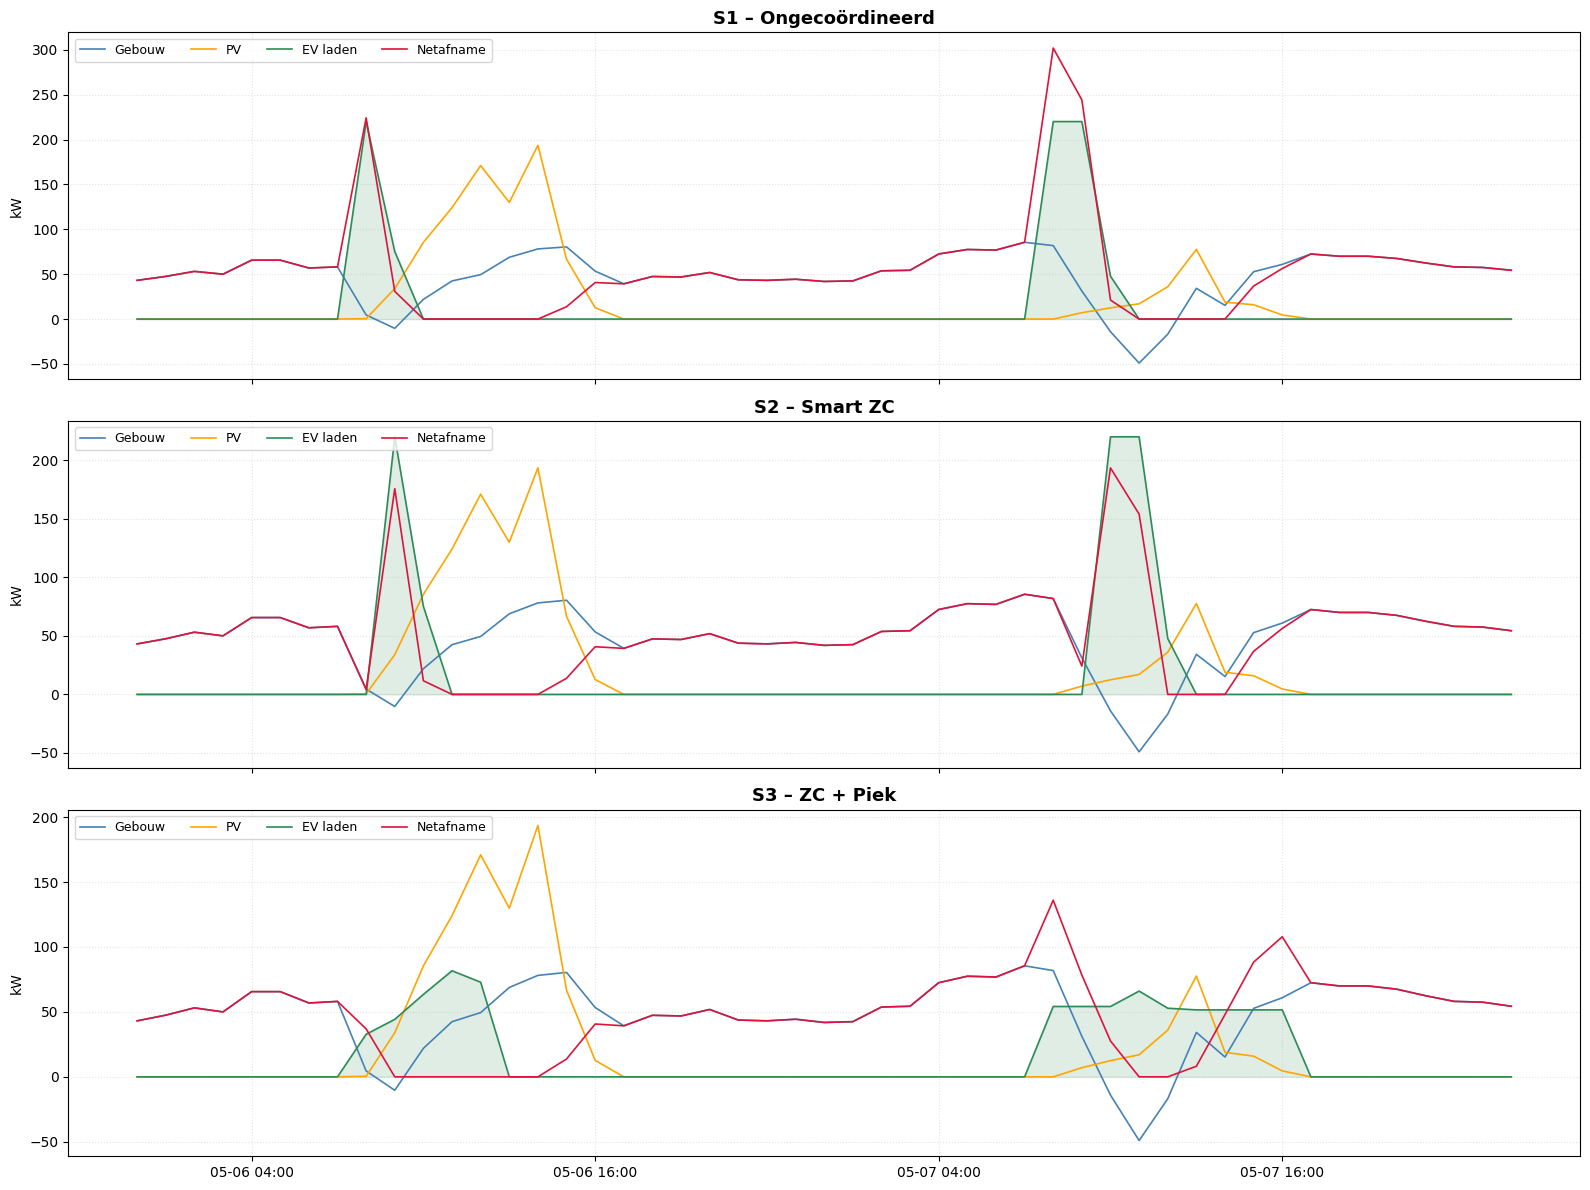

In [442]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# ============================================================
# SIMULATIEGRAFIEK: S1 vs S2 vs S3
# ============================================================

start_plot = pd.Timestamp('2025-05-06 00:00:00')
eind_plot = start_plot + pd.Timedelta(days=2)
df_sim = df_main.loc[start_plot:eind_plot].copy()

strategie_plot = {
    'S1 – Ongecoördineerd': ('P_laad_S1', 'P_net_S1'),
    'S2 – Smart ZC': ('P_laad_S2', 'P_net_S2'),
    'S3 – ZC + Piek': ('P_laad_S3', 'P_net_S3'),
}

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, (naam, (col_laad, col_net)) in zip(axes, strategie_plot.items()):
    gebouw = df_sim['totaal_verbruik_gebouw']
    pv = df_sim['productie_kwh']
    laad = df_sim[col_laad]
    net = df_sim[col_net]

    ax.plot(df_sim.index, gebouw, color='steelblue', linewidth=1.2, label='Gebouw')
    ax.plot(df_sim.index, pv, color='orange', linewidth=1.2, label='PV')
    ax.plot(df_sim.index, laad, color='seagreen', linewidth=1.2, label='EV laden')
    ax.plot(df_sim.index, net.clip(lower=0), color='crimson', linewidth=1.2, label='Netafname')

    ax.fill_between(df_sim.index, 0, laad, color='seagreen', alpha=0.15)
    ax.set_title(naam, fontsize=13, fontweight='bold')
    ax.set_ylabel('kW')
    ax.grid(True, linestyle=':', alpha=0.35)
    ax.legend(loc='upper left', ncols=4, fontsize=9)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=12))
plt.setp(axes[-1].get_xticklabels(), rotation=0, ha='center')
plt.tight_layout()
plt.show()

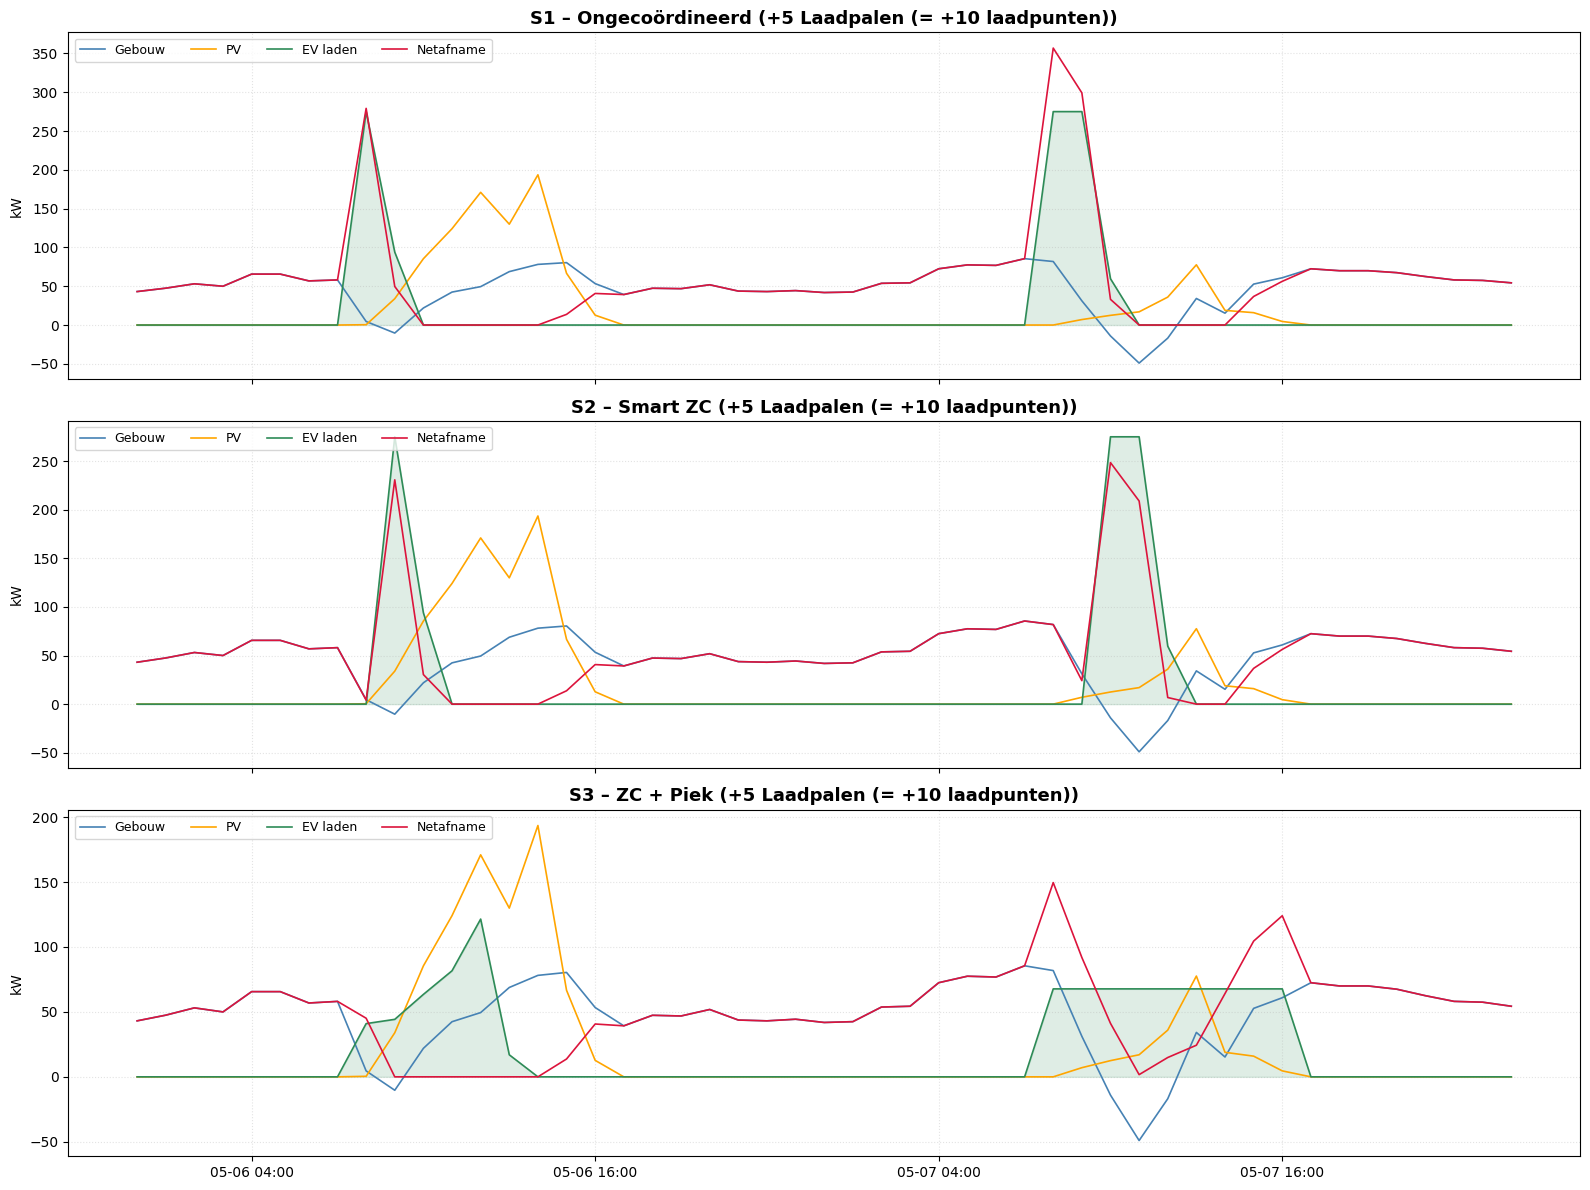

In [443]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ============================================================
# INSTELLINGEN EXTRA SCENARIO
# ============================================================
# Pas dit aan naar 'plus20p' als je de grafiek voor +10 laadpalen wilt zien!
suffix_scenario = 'plus10p' 
naam_scenario = '+5 Laadpalen (= +10 laadpunten)' 

# Selecteer dezelfde periode als je basisgrafiek
start_plot = pd.Timestamp('2025-05-06 00:00:00')
eind_plot = start_plot + pd.Timedelta(days=2)
df_sim = df_main.loc[start_plot:eind_plot].copy()

# Dynamisch de kolomnamen opbouwen op basis van de gekozen suffix
strategie_plot = {
    f'S1 – Ongecoördineerd ({naam_scenario})': (f'P_laad_S1_{suffix_scenario}', f'P_net_S1_{suffix_scenario}'),
    f'S2 – Smart ZC ({naam_scenario})': (f'P_laad_S2_{suffix_scenario}', f'P_net_S2_{suffix_scenario}'),
    f'S3 – ZC + Piek ({naam_scenario})': (f'P_laad_S3_{suffix_scenario}', f'P_net_S3_{suffix_scenario}'),
}

# ============================================================
# PLOTTEN
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, (naam, (col_laad, col_net)) in zip(axes, strategie_plot.items()):
    gebouw = df_sim['totaal_verbruik_gebouw']
    pv = df_sim['productie_kwh']
    laad = df_sim[col_laad]
    net = df_sim[col_net]

    # Teken de lijnen (GECOORRIGEERD: overal df_sim.index gebruikt)
    ax.plot(df_sim.index, gebouw, color='steelblue', linewidth=1.2, label='Gebouw')
    ax.plot(df_sim.index, pv, color='orange', linewidth=1.2, label='PV')
    ax.plot(df_sim.index, laad, color='seagreen', linewidth=1.2, label='EV laden')
    ax.plot(df_sim.index, net.clip(lower=0), color='crimson', linewidth=1.2, label='Netafname')

    # Schaduw onder de EV laadcurve
    ax.fill_between(df_sim.index, 0, laad, color='seagreen', alpha=0.15)
    
    # Layout instellingen per subplot
    ax.set_title(naam, fontsize=13, fontweight='bold')
    ax.set_ylabel('kW')
    ax.grid(True, linestyle=':', alpha=0.35)
    ax.legend(loc='upper left', ncols=4, fontsize=9)

# X-as opmaak (tijd)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=12))
plt.setp(axes[-1].get_xticklabels(), rotation=0, ha='center')

plt.tight_layout()
plt.show()